In [1]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio_10_percent'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)

# Stratified 70:30 train-test split
def stratified_split_70_30(X, y, test_size=0.2, random_state=42):
    """Split dataset into stratified 70/30 sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 80/30 split
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.2, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

Found 4522 audio files with corresponding labels.
Training set distribution: [1808 1808]
Test set distribution: [453 452]


In [ ]:
from tensorflow.keras.optimizers import Adam

# Define the CNN model
def create_cnn_model(input_shape):
    model = models.Sequential()

    # First Conv layer
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Second Conv layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Third Conv layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Flatten and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    
    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the model
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 37s 311ms/step - accuracy: 0.7174 - loss: 0.5621 - val_accuracy: 0.7602 - val_loss: 0.5264
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 345ms/step - accuracy: 0.7777 - loss: 0.4989 - val_accuracy: 0.7746 - val_loss: 0.5057
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 45s 397ms/step - accuracy: 0.7951 - loss: 0.4454 - val_accuracy: 0.7790 - val_loss: 0.4929
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - accuracy: 0.8111 - loss: 0.4056 - val_accuracy: 0.7845 - val_loss: 0.5088
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - accuracy: 0.8417 - loss: 0.3596 - val_accuracy: 0.7856 - val_loss: 0.4700
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 289ms/step - accuracy: 0.8539 - loss: 0.3335 - val_accuracy: 0.7989 - val_loss: 0.4191
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 301ms/step - accuracy: 0.8764 - loss: 0.2861 - val_accuracy: 0.8122 - val_loss: 0.4996
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 304ms/step - accuracy: 0.9049 - loss: 0

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 32s 263ms/step - accuracy: 0.7076 - loss: 0.5691 - val_accuracy: 0.7624 - val_loss: 0.5317
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.7978 - loss: 0.4554 - val_accuracy: 0.7646 - val_loss: 0.5160
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 55s 489ms/step - accuracy: 0.8049 - loss: 0.4541 - val_accuracy: 0.7790 - val_loss: 0.4938
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 40s 346ms/step - accuracy: 0.7954 - loss: 0.4340 - val_accuracy: 0.7768 - val_loss: 0.4879
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 40s 352ms/step - accuracy: 0.8159 - loss: 0.3975 - val_accuracy: 0.7890 - val_loss: 0.4617
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 291ms/step - accuracy: 0.8436 - loss: 0.3379 - val_accuracy: 0.8000 - val_loss: 0.4425
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 272ms/step - accuracy: 0.8812 - loss: 0.2943 - val_accuracy: 0.8033 - val_loss: 0.4510
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 276ms/step - accuracy: 0.8954 - loss: 0

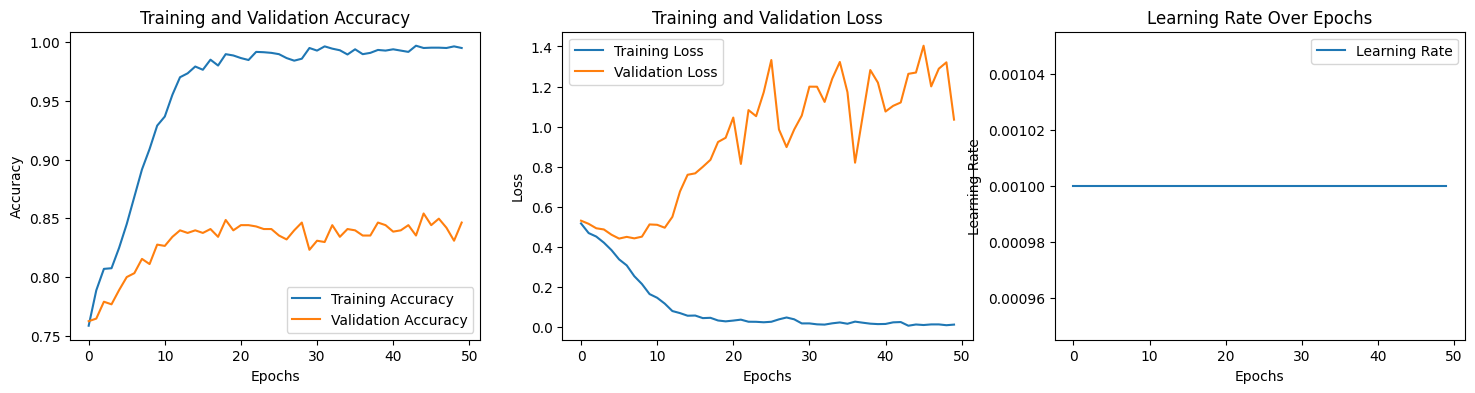

In [ ]:
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import tensorflow as tf

# Define the CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Second Conv layer
    model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Third Conv layer
    model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Flatten and add fully connected layers
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dropout(0.5))
    
    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Custom callback to record the learning rate each epoch
class LRCapture(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        self.model.history.history.setdefault('lr', []).append(lr)

# Create the model
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Learning rate capture callback
lr_capture = LRCapture()

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[lr_capture])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy, loss, and learning rate
plt.figure(figsize=(18, 4))

# Plot accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()



plt.show()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,241 (3.15 MB)

 Trainable params: 826,241 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.6935 - loss: 0.7074 - val_accuracy: 0.7481 - val_loss: 0.5863
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.7770 - loss: 0.5500 - val_accuracy: 0.7602 - val_loss: 0.5642
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.7852 - loss: 0.5414 - val_accuracy: 0.7646 - val_loss: 0.5698
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.7871 - loss: 0.5320 - val_accuracy: 0.7635 - val_loss: 0.5590
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.7842 - loss: 0.5166 - val_accuracy: 0.7558 - val_loss: 0.5571
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.7941 - loss: 0.4992 - val_accuracy: 0.7669 - val_loss: 0.5468
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.7840 - loss: 0.5022 - val_accuracy: 0.7669 - val_loss: 0.5399
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.7782 - loss: 0.5087 -

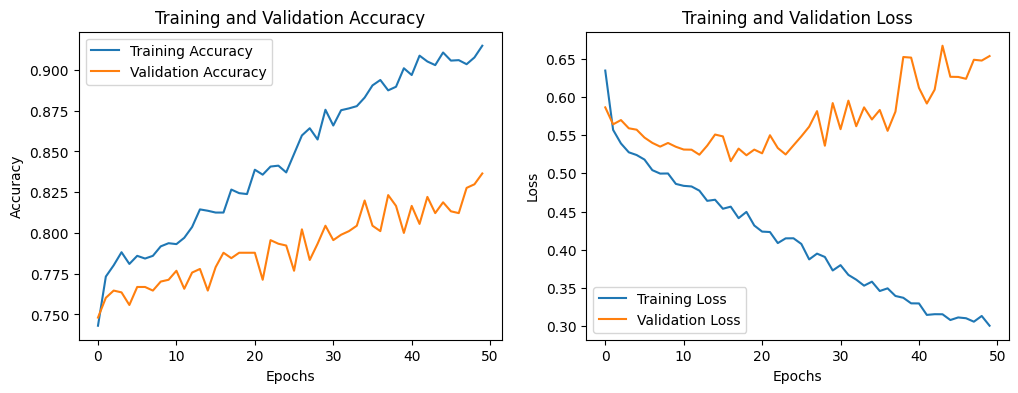

In [7]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import matplotlib.pyplot as plt

# Define the CNN model with modified parameters to reduce overfitting
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with reduced filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Second Conv layer with reduced filters
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Third Conv layer with reduced filters
    model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Flatten and add fully connected layers with increased dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.6))  # Increased dropout

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Create the model with the modified parameters
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,425 (1.55 MB)

 Trainable params: 407,425 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.6606 - loss: 0.7097 - val_accuracy: 0.7503 - val_loss: 0.5877
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7590 - loss: 0.5849 - val_accuracy: 0.7503 - val_loss: 0.5722
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7613 - loss: 0.5602 - val_accuracy: 0.7558 - val_loss: 0.5598
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7727 - loss: 0.5554 - val_accuracy: 0.7536 - val_loss: 0.5749
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7795 - loss: 0.5342 - val_accuracy: 0.7525 - val_loss: 0.5585
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7728 - loss: 0.5250 - val_accuracy: 0.7569 - val_loss: 0.5454
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7867 - loss: 0.5328 - val_accuracy: 0.7591 - val_loss: 0.5397
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7850 - loss: 0.5250 - val_accu

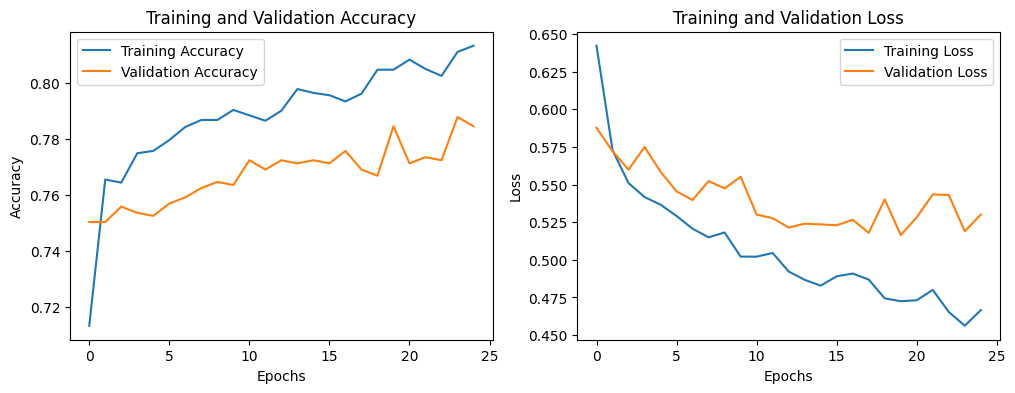

In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import matplotlib.pyplot as plt

# Define the CNN model with adjusted parameters to reduce overfitting
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(8, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Second Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Third Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Flatten and add fully connected layers with increased dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.7))  # Increased dropout to reduce overfitting

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Create the model with the modified parameters
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.6433 - loss: 0.9088 - val_accuracy: 0.7539 - val_loss: 0.6480
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7732 - loss: 0.6021 - val_accuracy: 0.7531 - val_loss: 0.6001
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7833 - loss: 0.5671 - val_accuracy: 0.7634 - val_loss: 0.5811
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7862 - loss: 0.5389 - val_accuracy: 0.7679 - val_loss: 0.5641
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7846 - loss: 0.5386 - val_accuracy: 0.7627 - val_loss: 0.5896
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7883 - loss: 0.5145 - val_accuracy: 0.7634 - val_loss: 0.5502
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7874 - loss: 0.5010 - val_accuracy: 0.7745 - val_loss: 0.5362
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8088 - loss: 0.4857 - val_accuracy: 0.

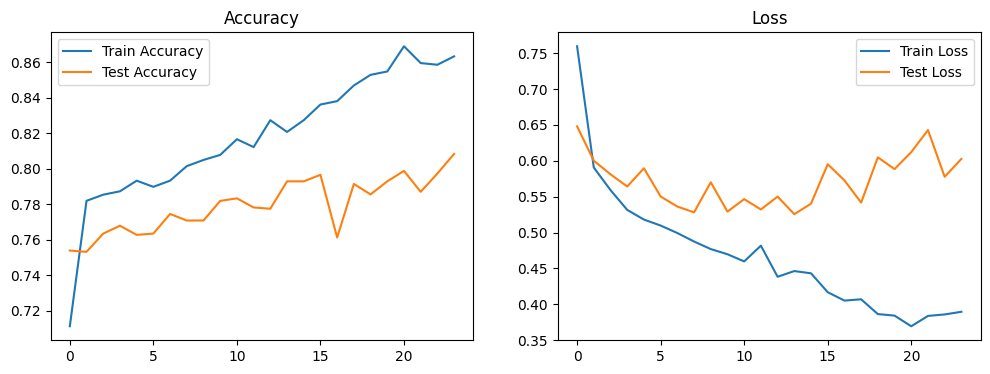

In [15]:

# Define the CNN model with regularization and increased dropout
def create_cnn_model(input_shape):
    model = models.Sequential()

    # First Conv layer
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(0.001)))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Second Conv layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Third Conv layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Flatten and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(layers.Dropout(0.6))  # Increase dropout to 0.6
    
    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the model
input_shape = (224, 224, 3)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a reduced learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Early stopping callback to stop training if validation loss doesn't improve
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [9]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import matplotlib.pyplot as plt

# Define the CNN model with modified parameters to fit the given specifications
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with 16 filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))  # Output shape will be approximately (100, 100, 16)
    
    # Flatten and add fully connected layers with dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.6))  # Dropout for regularization

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Create the model with the specified input shape
input_shape = (200, 200, 3)  # Audio features input dimension
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with binary cross-entropy loss for binary classification
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model with specified epochs and steps per epoch
history = model.fit(
    X_train, y_train, 
    epochs=30,               # Specified in the table
    steps_per_epoch=8,       # Specified in the table
    batch_size=32, 
    validation_data=(X_test, y_test)
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 156816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │    10,036,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,036,801 (38.29 MB)

 Trainable params: 10,036,801 (38.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv2d_21" is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (32, 128, 128, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 128, 128, 1), dtype=float32)
  • training=True
  • mask=None